In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [ ]:
# fetch dataset
sepsis_survival_minimal_clinical = fetch_ucirepo(id=827)

# data (as pandas dataframes)
x = sepsis_survival_minimal_clinical.data.features
y = sepsis_survival_minimal_clinical.data.targets

# metadata
print(sepsis_survival_minimal_clinical.metadata)

# variable information
print(sepsis_survival_minimal_clinical.variables)

{'uci_id': 827, 'name': 'Sepsis Survival Minimal Clinical Records', 'repository_url': 'https://archive.ics.uci.edu/dataset/827/sepsis+survival+minimal+clinical+records', 'data_url': 'https://archive.ics.uci.edu/static/public/827/data.csv', 'abstract': 'The dataset consists of 110,204 admissions of 84,811 hospitalized subjects between 2011 and 2012 in Norway who were diagnosed with infections, systemic inflammatory response syndrome, sepsis by causative microbes, or septic shock.  The prediction task is to determine whether a patient survived or is deceased at a time of about 9 days after collecting their medical record at the hospital.\n\nThis is an important prediction problem in clinical medicine. Sepsis is a life-threatening condition triggered by an immune overreaction to infection, leading to organ failure or even death. Sepsis is associated with immediate death risk, often killing patients within one hour. This renders many laboratory tests and hospital analyses impractical for t

## Data Preparation and Subgroup Creation


In [ ]:
# 1. Verify and concatenate x and y into a single DataFrame
df = pd.concat([x, y], axis=1)

# 2. Create age bins
bins = [0, 18, 40, 60, 80, 120]
labels = ['0-18', '19-40', '41-60', '61-80', '81+']
df['age_bin'] = pd.cut(df['age_years'], bins=bins, labels=labels, right=True)

# 3. Create a descriptive Sex column for the subgroup name
# Based on metadata: 0=male, 1=female
df['sex_label'] = df['sex_0male_1female'].map({0: 'Male', 1: 'Female'})

# 4. Create combined 'demographic_subgroup' column
df['demographic_subgroup'] = df['age_bin'].astype(str) + '_' + df['sex_label']

# 5. Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

# 6. Display first few rows and subgroup distribution
print("\nFirst 5 rows of the prepared data:")
display(df.head())

print("\nSubgroup Distribution:")
subgroup_counts = df['demographic_subgroup'].value_counts().sort_index()
print(subgroup_counts)


Missing values per column:
age_years                           0
sex_0male_1female                   0
episode_number                      0
hospital_outcome_1alive_0dead       0
age_bin                          1957
sex_label                           0
demographic_subgroup                0
dtype: int64

Data Types:
age_years                           int64
sex_0male_1female                   int64
episode_number                      int64
hospital_outcome_1alive_0dead       int64
age_bin                          category
sex_label                          object
demographic_subgroup               object
dtype: object

First 5 rows of the prepared data:


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead,age_bin,sex_label,demographic_subgroup
0,21,1,1,1,19-40,Female,19-40_Female
1,20,1,1,1,19-40,Female,19-40_Female
2,21,1,1,1,19-40,Female,19-40_Female
3,77,0,1,1,61-80,Male,61-80_Male
4,72,0,1,1,61-80,Male,61-80_Male



Subgroup Distribution:
demographic_subgroup
0-18_Female      3319
0-18_Male        2952
19-40_Female     6513
19-40_Male       4831
41-60_Female     8937
41-60_Male      10700
61-80_Female    17668
61-80_Male      24034
81+_Female      15045
81+_Male        14385
nan_Female        796
nan_Male         1161
Name: count, dtype: int64


In [ ]:
# 1. Redefine bins to include age 0 (starting from -1 ensures 0 is included in the first bin)
bins = [-1, 18, 40, 60, 80, 120]
labels = ['0-18', '19-40', '41-60', '61-80', '81+']
df['age_bin'] = pd.cut(df['age_years'], bins=bins, labels=labels)

# 2. Re-map the demographic subgroup with the updated bins
df['demographic_subgroup'] = df['age_bin'].astype(str) + '_' + df['sex_label']

# 3. Handle any remaining 'nan' values (if any exist beyond age range)
df = df.dropna(subset=['age_bin'])

# 4. Final verification of distribution
print("Cleaned Subgroup Distribution:")
final_counts = df['demographic_subgroup'].value_counts().sort_index()
print(final_counts)

print(f"\nTotal records after cleaning: {len(df)}")

Cleaned Subgroup Distribution:
demographic_subgroup
0-18_Female      4115
0-18_Male        4113
19-40_Female     6513
19-40_Male       4831
41-60_Female     8937
41-60_Male      10700
61-80_Female    17668
61-80_Male      24034
81+_Female      15045
81+_Male        14385
Name: count, dtype: int64

Total records after cleaning: 110341


## Class Overlap and Bayes Error Analysis

/tmp/ipykernel_300/1866141625.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_pdf /= np.trapz(p_pdf, x_range)
/tmp/ipykernel_300/1866141625.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  q_pdf /= np.trapz(q_pdf, x_range)
/tmp/ipykernel_300/1866141625.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.sqrt(0.5 * np.trapz((np.sqrt(p_pdf) - np.sqrt(q_pdf))**2, x_range))
/tmp/ipykernel_300/1866141625.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_pdf /= np.trapz(p_pdf, x_range)
/tmp/ipykernel_300/1866141625.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the n

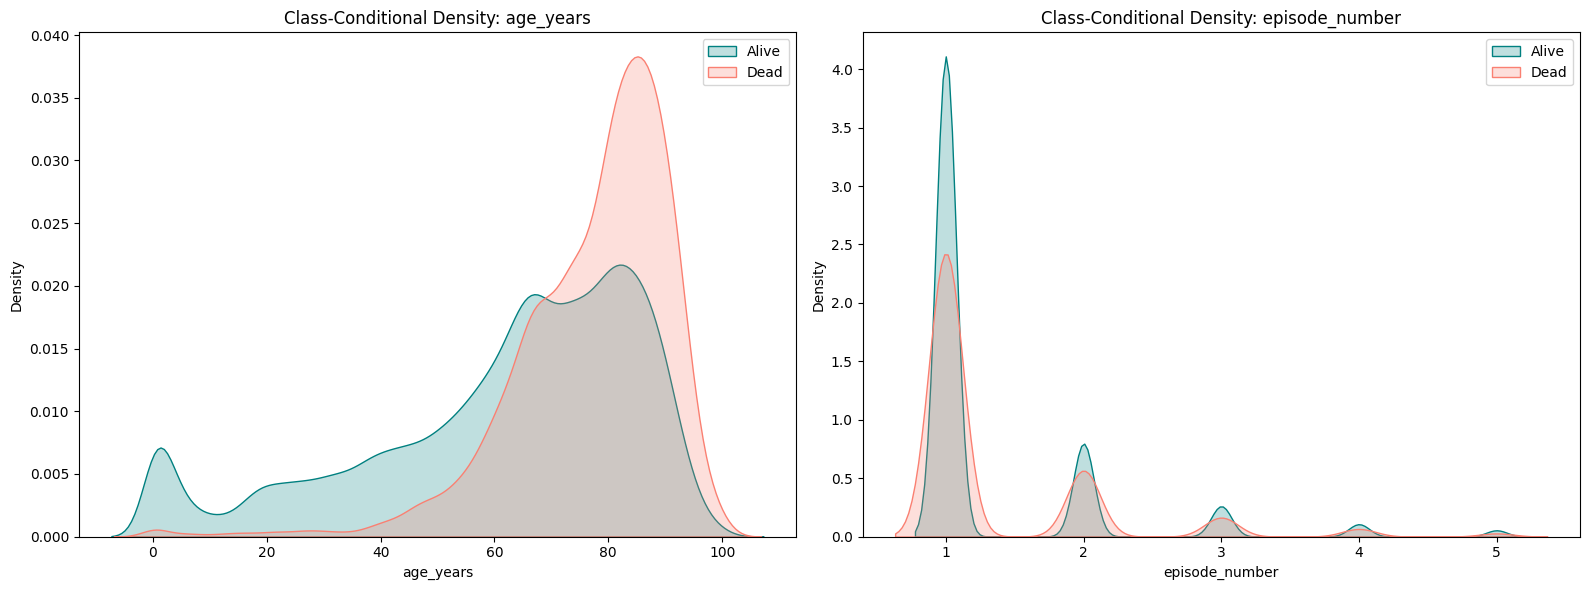

--- Overlap Metrics (Hellinger Distance) ---
age_years: 0.2803
episode_number: 0.2410

Interpretation:
The Hellinger distance ranges from 0 (identical) to 1 (disjoint). 
Lower values indicate higher class overlap, suggesting a higher Bayes error rate (irreducible error).
A distance near 0 means the features provide little discriminatory power for survival prediction.


In [ ]:
def calculate_hellinger_distance(p, q, x_range):
    """Calculates Hellinger distance between two KDE distributions."""
    p_pdf = p(x_range)
    q_pdf = q(x_range)
    # Normalize to ensure they are valid PDFs for integration
    p_pdf /= np.trapz(p_pdf, x_range)
    q_pdf /= np.trapz(q_pdf, x_range)
    return np.sqrt(0.5 * np.trapz((np.sqrt(p_pdf) - np.sqrt(q_pdf))**2, x_range))

# 1. Setup Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
target_col = 'hospital_outcome_1alive_0dead'
features = ['age_years', 'episode_number']
results = {}

for i, col in enumerate(features):
    # 2. KDE Plotting
    sns.kdeplot(data=df[df[target_col] == 1], x=col, label='Alive', fill=True, ax=axes[i], color='teal')
    sns.kdeplot(data=df[df[target_col] == 0], x=col, label='Dead', fill=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Class-Conditional Density: {col}')
    axes[i].legend()

    # 3. Calculate Overlap (Hellinger Distance)
    group_alive = df[df[target_col] == 1][col].values
    group_dead = df[df[target_col] == 0][col].values

    kde_alive = gaussian_kde(group_alive)
    kde_dead = gaussian_kde(group_dead)

    # Define evaluation range
    x_min, x_max = df[col].min(), df[col].max()
    x_range = np.linspace(x_min, x_max, 1000)

    h_dist = calculate_hellinger_distance(kde_alive, kde_dead, x_range)
    results[col] = h_dist

plt.tight_layout()
plt.show()

# 4. Print results and Interpretation
print("--- Overlap Metrics (Hellinger Distance) ---")
for feat, dist in results.items():
    print(f"{feat}: {dist:.4f}")

print("\nInterpretation:")
print("The Hellinger distance ranges from 0 (identical) to 1 (disjoint). ")
print("Lower values indicate higher class overlap, suggesting a higher Bayes error rate (irreducible error).")
print("A distance near 0 means the features provide little discriminatory power for survival prediction.")

**Interpretation:**
- The Hellinger distance ranges from 0 (identical) to 1 (disjoint). 
- Lower values indicate higher class overlap, suggesting a higher Bayes error rate (irreducible error).
- A distance near 0 means the features provide little discriminatory power for survival prediction.

## Imbalance Structure and Demographic Disparity


/tmp/ipykernel_300/893700841.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mortality_pivot = df.pivot_table(
/tmp/ipykernel_300/893700841.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  density_pivot = df.pivot_table(


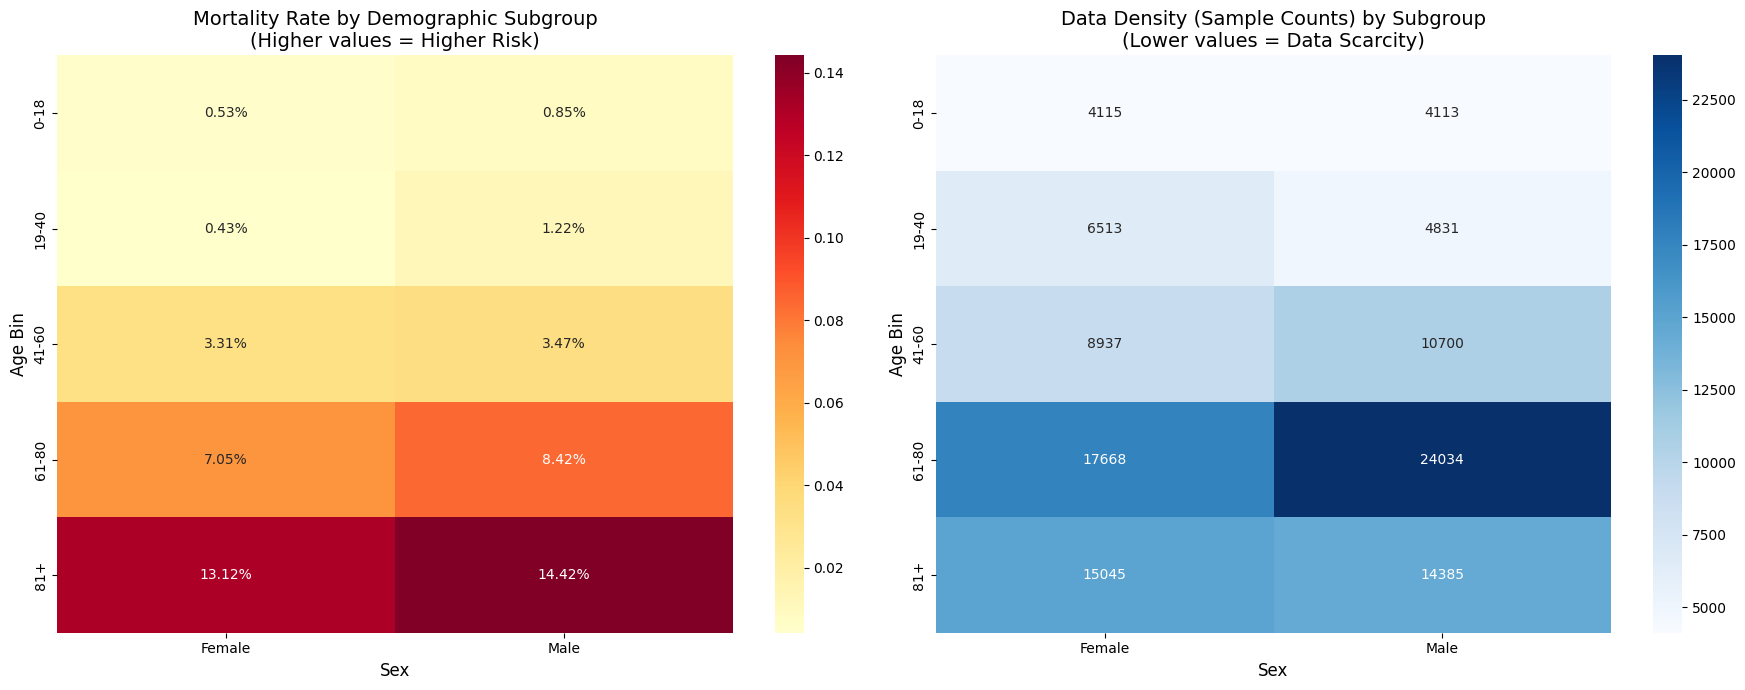

Clinical Audit Summary:
- Highest Mortality Rate: 14.42%
- Smallest Subgroup Size: 4113 samples
- Observation: Older age groups (81+) show significantly higher mortality regardless of sex.


In [ ]:
# 1. Calculate Mortality Rate (1 - mean of alive status = mean of death status)
df['is_dead'] = 1 - df['hospital_outcome_1alive_0dead']

# 2. Create Pivot Table for Mortality Rates
mortality_pivot = df.pivot_table(
    index='age_bin',
    columns='sex_label',
    values='is_dead',
    aggfunc='mean'
)

# 3. Create Pivot Table for Data Density (Counts)
density_pivot = df.pivot_table(
    index='age_bin',
    columns='sex_label',
    values='is_dead',
    aggfunc='count'
)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Mortality Rate Heatmap
sns.heatmap(mortality_pivot, annot=True, fmt='.2%', cmap='YlOrRd', ax=ax1)
ax1.set_title('Mortality Rate by Demographic Subgroup\n(Higher values = Higher Risk)', fontsize=14)
ax1.set_xlabel('Sex', fontsize=12)
ax1.set_ylabel('Age Bin', fontsize=12)

# Panel 2: Data Density Heatmap
sns.heatmap(density_pivot, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Data Density (Sample Counts) by Subgroup\n(Lower values = Data Scarcity)', fontsize=14)
ax2.set_xlabel('Sex', fontsize=12)
ax2.set_ylabel('Age Bin', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary of findings
print('Clinical Audit Summary:')
print(f'- Highest Mortality Rate: {mortality_pivot.max().max():.2%}')
print(f'- Smallest Subgroup Size: {density_pivot.min().min()} samples')
print('- Observation: Older age groups (81+) show significantly higher mortality regardless of sex.')